In [1]:
import numpy as np
import scipy
from tueplots import bundles
import matplotlib.pyplot as plt
## setting matplotlib context
from cycler import cycler
from matplotlib.cm import get_cmap
cmap = get_cmap("tab10",8)
palette = [cmap(i) for i in range(8)]
rc = bundles.neurips2024(usetex=False)
rc.update({
    # Set the line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})
np.random.seed(0)


/var/folders/cx/cy7pq56x7m32_zfmgnslz8cnlnlryt/T/ipykernel_88016/2843679705.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10",8)


### Outline:

1. Using a finite superset D_shadow, train M shadow models.
2. Compute P_in and P_out per sample in the superset from these shadow models.
   
[TRAIN PHASE]

Train M_test models on subsets of D_shadow and evaluate TPR/FPR PX for them using the P_in and P_out.

[TEST PHASE]

1. For each sample in the superset, build new sets (with M_test) of D_in/ D_out based on LOO with remaining samples drawn fresh from population.
2. Re-compute IN/ OUT scores for each sample.
3. Use P_in and P_out computed from shadow models trained on superset to compute average TPR/FPR PX on the M_test models.

In [ ]:
np.random.seed(0)

N = 500
d = 500
N_train = int(N//2)
# N_train = 100
sigma = 1.0
eps = 1e-12
M = 512
M_test = 512

# Target Superset #
X = scipy.stats.norm.rvs(loc=0.0, scale=sigma, size=(N,d))

# Membership Matrix #
memberships = np.zeros((M + M_test, N), dtype=bool)
for r in range(M + M_test):
    idx = np.random.choice(N, size=N_train, replace=False)
    memberships[r, idx] = True

# Computing Model Statistics #
model_means = (memberships @ X) / N_train   # (M+M_test,)
# model_means, X = np.expand_dims(model_means,axis=1), np.expand_dims(X,axis=1)
stats      = model_means @ X.T             # (M+M_test, N)

# Splitting the test models trained from superset and shadow models for stats #
shadow_test_stats, shadow_test_indices = stats[:M_test,:], memberships[:M_test,:]
shadow_stats, shadow_indices = stats[M_test:,:], memberships[M_test:,:]

In [20]:
mu_ins, mu_outs ,sigma_ins, sigma_outs = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
for n in range(N):
    curr_stats, curr_indices = shadow_stats[:,n], shadow_indices[:,n]
    in_stats, out_stats = curr_stats[curr_indices], curr_stats[~curr_indices]
    mu_ins[n], mu_outs[n], sigma_ins[n], sigma_outs[n] = np.mean(in_stats), np.mean(out_stats), np.std(in_stats), np.std(out_stats)

In [31]:
def compute_llr_grid(
    stats:     np.ndarray,  # (K, N)
    mu_ins:    np.ndarray,  # (N,)
    mu_outs:   np.ndarray,  # (N,)
    sigma_ins:  np.ndarray, # (N,)
    sigma_outs: np.ndarray, # (N,)
    eps: float = 1e-8,
) -> np.ndarray:            # (K, N)
    return (
        np.log(sigma_ins + eps) - np.log(sigma_outs + eps)
        + 0.5 * (stats - mu_outs) ** 2 / (sigma_outs + eps) ** 2
        - 0.5 * (stats - mu_ins)  ** 2 / (sigma_ins  + eps) ** 2
    )
alpha = 0.01
# Shadow eval — compressed stds, shadow tau (FPR ≈ α by construction)
# TPR here is inflated due to compressed stds

shadow_test_llrs = compute_llr_grid(shadow_test_stats, mu_ins, mu_outs, sigma_ins, sigma_outs)

tau_px = np.nanquantile(np.where(~shadow_test_indices, shadow_test_llrs, np.nan), 1 - alpha, axis=0)
tpr_px_shadow = (((shadow_test_llrs > tau_px) & shadow_test_indices).sum(axis=0)
                / shadow_test_indices.sum(axis=0))
fpr_px_shadow = (((shadow_test_llrs > tau_px) & ~shadow_test_indices).sum(axis=0)
                / (~shadow_test_indices).sum(axis=0))
print(tpr_px_shadow.mean(),fpr_px_shadow.mean())

0.41656889115470197 0.011741500122589869


In [22]:
## ----------------
# FPC Computation
## ----------------

# fpc_in  = 1.0 - (N_train - 1) / (N - 1)
# fpc_out = 1.0 - N_train       / (N - 1)

fpc_in = fpc_out = 1.0 - N_train       / (N - 1)

sigma_ins_corr  = sigma_ins  / np.sqrt(fpc_in)
sigma_outs_corr = sigma_outs / np.sqrt(fpc_out)

In [ ]:
# # In the train phase cell — compute both taus
# shadow_test_llrs_uncorr = compute_llr_grid(shadow_test_stats, mu_ins, mu_outs, sigma_ins, sigma_outs)
# shadow_test_llrs_corr   = compute_llr_grid(shadow_test_stats, mu_ins, mu_outs, sigma_ins_corr, sigma_outs_corr)

# tau_px_corr   = np.nanquantile(np.where(~shadow_test_indices, shadow_test_llrs_corr,   np.nan), 1 - alpha, axis=0)

In [23]:
stats_test_in, stats_test_out = np.zeros((M_test//2,N)), np.zeros((M_test//2,N))
for n in range(N):
    # population-based test sets
    # for a single element, assume we have M_test (IN + OUT) test models build on LOO principle.
    X_test_out = scipy.stats.norm.rvs(loc=0.0, scale=sigma, size=(M_test//2,N_train, d))
    X_test_in = np.copy(X_test_out)
    X_test_in[:,0,:] = np.expand_dims(X[n],axis=0)
    in_sums, out_sums = X_test_in.mean(axis=1), X_test_out.mean(axis=1)
    stats_test_in[:,n], stats_test_out[:,n] = in_sums @ X[n], out_sums @ X[n]


In [30]:
# Test eval — corrected stds, tau re-calibrated on test OUT scores
alpha = 0.01
pop_test_llrs_in_c  = compute_llr_grid(stats_test_in,  mu_ins, mu_outs, sigma_ins_corr, sigma_outs_corr)
pop_test_llrs_out_c = compute_llr_grid(stats_test_out, mu_ins, mu_outs, sigma_ins_corr, sigma_outs_corr)

tau_test = np.quantile(pop_test_llrs_out_c, 1 - alpha, axis=0)  # calibrated on test OUT

tpr_test = (pop_test_llrs_in_c  > tau_test).mean(axis=0)
fpr_test = (pop_test_llrs_out_c > tau_test).mean(axis=0)

print(tpr_test.mean(), fpr_test.mean())

0.2062109375 0.01171875


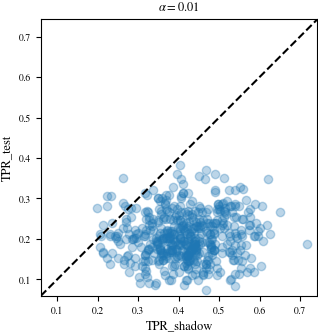

In [41]:
rc = bundles.neurips2024(usetex=False)
rc.update({
    # Set the line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})

with plt.rc_context(rc):
    fig, ax = plt.subplots(1, 1)
    
    ax.scatter(tpr_px_shadow, tpr_test, alpha=0.3)
    # ax.hist(tpr_px_shadow, bins=25,alpha=0.5)
    # ax.hist(tpr_test, bins=25,alpha=0.5)
    ax.set_box_aspect(1)
    ax.set(xlabel="TPR_shadow", ylabel="TPR_test")
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    lim_min = min(xlim[0], ylim[0])
    lim_max = max(xlim[1], ylim[1])

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.plot([lim_min, lim_max], [lim_min, lim_max],"k--")
    ax.set_title(rf"$\alpha = {alpha}$")
    plt.savefig("test_plot.pdf",bbox_inches="tight")
    plt.show()


### Objective 1:  Analytical vs. Empirical Standard Deviations

In [ ]:
X_norm  = np.linalg.norm(X, axis=1)     
analytical_sigma_out = sigma * X_norm / np.sqrt(N_train)
analytical_sigma_in  = sigma * X_norm * np.sqrt(N_train - 1) / N_train

# fpc_in  = 1.0 - (N_train - 1) / (N - 1)
# fpc_out = 1.0 - N_train       / (N - 1)

fpc_in = fpc_out = 1.0 - N_train       / (N - 1)

sigma_ins_corr  = sigma_ins  / np.sqrt(fpc_in)
sigma_outs_corr = sigma_outs / np.sqrt(fpc_out)

print("── IN std comparison (mean over samples) ──")
print(f"  analytical:          {analytical_sigma_in.mean():.6f}")
print(f"  empirical (raw):     {sigma_ins.mean():.6f}")
print(f"  empirical / √fpc_in: {sigma_ins_corr.mean():.6f}")
print()
print("── OUT std comparison (mean over samples) ──")
print(f"  analytical:           {analytical_sigma_out.mean():.6f}")
print(f"  empirical (raw):      {sigma_outs.mean():.6f}")
print(f"  empirical / √fpc_out: {sigma_outs_corr.mean():.6f}")

In [ ]:
rc = bundles.neurips2024(usetex=False,rel_width=0.5)
rc.update({
    # Set the line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})

with plt.rc_context(rc):
    fig, ax = plt.subplots(1, 2, sharex="row", sharey="row")

    plots = [
        ("OUT", analytical_sigma_out, sigma_outs, sigma_outs_corr),
        ("IN",  analytical_sigma_in,  sigma_ins,  sigma_ins_corr),
    ]

    for i, (label, analytical, empirical, corrected) in enumerate(plots):
        # sort by analytical std for a clean line plot
        order = np.argsort(analytical)

        ax[i].plot(
            analytical[order],
            color="r",
            label="Analytical",
            lw=1.5,
            
        )
        ax[i].plot(
            empirical[order],
            label="W/ LiRA",
            lw=1.5,
            ls="--",
            alpha=0.65
        )
        ax[i].plot(
            corrected[order],
            label="post-FPC",
            lw=1.5,
            ls=":",
            alpha=0.65
        )

        ax[i].set_title(rf"{label}")
        ax[i].set_xlabel(r"$X$s")
        ax[i].set_box_aspect(1)

    ax[0].set_ylabel(r"$\sigma$")

    h, l = ax[0].get_legend_handles_labels()
    fig.legend(
        h, l,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.15),
        ncol=3,
        frameon=False,
    )
    # plt.savefig("stdev_pre_post_fpc_lira.pdf", bbox_inches="tight")
    plt.show()

In [ ]:
# Ratio: corrected_empirical / analytical  (should be ≈ 1.0 if FPC rule is accurate)
ratio_in  = sigma_ins_corr  / analytical_sigma_in
ratio_out = sigma_outs_corr / analytical_sigma_out

# Also check raw compression ratio vs predicted compression from FPC
raw_ratio_in  = sigma_ins  / analytical_sigma_in   # should be ≈ √fpc_in
raw_ratio_out = sigma_outs / analytical_sigma_out  # should be ≈ √fpc_out

print("── Does empirical compression match FPC prediction? ──")
print(f" (IN) Raw Ratio:  {raw_ratio_in.mean():.6f}  (expected √fpc_in  = {np.sqrt(fpc_in):.6f})")
print(f" (OUT) Raw Ratio: {raw_ratio_out.mean():.6f}  (expected √fpc_out = {np.sqrt(fpc_out):.6f})")
print()
print("── After FPC correction (corrected/analytical, should be ≈ 1.0) ──")
print(f"  IN  — mean: {ratio_in.mean():.6f},  std: {ratio_in.std():.6f},  max|err|: {np.abs(ratio_in - 1).max():.6f}")
print(f"  OUT — mean: {ratio_out.mean():.6f},  std: {ratio_out.std():.6f},  max|err|: {np.abs(ratio_out - 1).max():.6f}")

In [ ]:
rc = bundles.neurips2024(usetex=False, rel_width=0.5)
rc.update({
    # Set the line/bar color cycle (this is what affects ax.plot)
    "axes.prop_cycle": cycler(color=palette),
    # Optional readability tweaks
    "legend.frameon": False,
    "axes.grid": False,
})

with plt.rc_context(rc):
    fig, ax = plt.subplots(1,2, sharey="row")

    ax[0].hist(raw_ratio_in, bins=25, density=True, alpha=0.65)
    ax[0].axvline(np.sqrt(fpc_in), color="red",  lw=1.5, ls="--", label=rf"$\sqrt{{\mathrm{{FPC}}}}$ = {np.sqrt(fpc_in):.4f}")
    ax[0].set_title("IN")
    ax[0].set_xlabel(r"$\dfrac{{\sigma_{emp}}}{{\sigma_{ana}}}$")
    ax[0].set_box_aspect(1)
    # ax[0].legend()

    ax[1].hist(raw_ratio_out, bins=25, density=True, alpha=0.65)
    ax[1].axvline(np.sqrt(fpc_out), color="red",  lw=1.5, ls="--", label=rf"$\sqrt{{\mathrm{{FPC}}}}$ = {np.sqrt(fpc_out):.4f}")
    ax[1].set_title("OUT")
    ax[1].set_xlabel(r"$\dfrac{{\sigma_{emp}}}{{\sigma_{ana}}}$")
    ax[1].set_box_aspect(1)
    # ax[1].legend()

    h, l = ax[0].get_legend_handles_labels()
    fig.legend(
        h, l,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.15),
        ncol=3,
        frameon=False,
    )

    # plt.savefig("fpc_compression_ratio.pdf", bbox_inches="tight")

    plt.show()


### Objective 3: Illustrate that the reported TPR value is affected by the finite population bias

In [ ]:
def compute_llr_grid(
    stats:     np.ndarray,  # (K, N)
    mu_ins:    np.ndarray,  # (N,)
    mu_outs:   np.ndarray,  # (N,)
    sigma_ins:  np.ndarray, # (N,)
    sigma_outs: np.ndarray, # (N,)
    eps: float = 1e-8,
) -> np.ndarray:            # (K, N)
    return (
        np.log(sigma_ins + eps) - np.log(sigma_outs + eps)
        + 0.5 * (stats - mu_outs) ** 2 / (sigma_outs + eps) ** 2
        - 0.5 * (stats - mu_ins)  ** 2 / (sigma_ins  + eps) ** 2
    )

In [ ]:
np.random.seed(0)

N = 2000
d = 500
# N_train = int(N//2)
# N_train = 100
sigma = 1.0
alpha = 0.01
eps = 1e-12
M = 512
M_test = 512

# Target Superset #
X = scipy.stats.norm.rvs(loc=0.0, scale=sigma, size=(N,d))

In [ ]:
R = [1/4,1/3,1/2]

shadow_tprs, test_tprs = [],[]
for r in R:
    N_train = int(N*r)
    # print(N_train)
    # Membership Matrix #
    memberships = np.zeros((M + M_test, N), dtype=bool)
    for r in range(M + M_test):
        idx = np.random.choice(N, size=N_train, replace=False)
        memberships[r, idx] = True

    # Computing Model Statistics #
    model_means = (memberships @ X) / N_train   # (M+M_test,)
    # model_means, X = np.expand_dims(model_means,axis=1), np.expand_dims(X,axis=1)
    stats      = model_means @ X.T             # (M+M_test, N)

    # Splitting the test models trained from superset and shadow models for stats #
    shadow_test_stats, shadow_test_indices = stats[:M_test,:], memberships[:M_test,:]
    shadow_stats, shadow_indices = stats[M_test:,:], memberships[M_test:,:]

    mu_ins, mu_outs ,sigma_ins, sigma_outs = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    for n in range(N):
        curr_stats, curr_indices = shadow_stats[:,n], shadow_indices[:,n]
        in_stats, out_stats = curr_stats[curr_indices], curr_stats[~curr_indices]
        mu_ins[n], mu_outs[n], sigma_ins[n], sigma_outs[n] = np.mean(in_stats), np.mean(out_stats), np.std(in_stats), np.std(out_stats)

    # Shadow eval — compressed stds, shadow tau (FPR ≈ α by construction)
    # TPR here is inflated due to compressed stds

    shadow_test_llrs = compute_llr_grid(shadow_test_stats, mu_ins, mu_outs, sigma_ins, sigma_outs)

    tau_px = np.nanquantile(np.where(~shadow_test_indices, shadow_test_llrs, np.nan), 1 - alpha, axis=0)
    tpr_px_shadow = (((shadow_test_llrs > tau_px) & shadow_test_indices).sum(axis=0)
                    / shadow_test_indices.sum(axis=0))
    # fpr_px_shadow = (((shadow_test_llrs > tau_px) & ~shadow_test_indices).sum(axis=0)
    #                 / (~shadow_test_indices).sum(axis=0))
    print("Shadow Eval (TPR,FPR):",tpr_px_shadow.mean(),fpr_px_shadow.mean())

    # FPC Correction 
    fpc_in = fpc_out = 1.0 - N_train       / (N - 1)

    sigma_ins_corr  = sigma_ins  / np.sqrt(fpc_in)
    sigma_outs_corr = sigma_outs / np.sqrt(fpc_out)

    # Building test case
    stats_test_in, stats_test_out = np.zeros((M_test//2,N)), np.zeros((M_test//2,N))
    for n in range(N):
        # population-based test sets
        # for a single element, assume we have M_test (IN + OUT) test models build on LOO principle.
        X_test_out = scipy.stats.norm.rvs(loc=0.0, scale=sigma, size=(M_test//2,N_train, d))
        X_test_in = np.copy(X_test_out)
        X_test_in[:,0,:] = np.expand_dims(X[n],axis=0)
        in_sums, out_sums = X_test_in.mean(axis=1), X_test_out.mean(axis=1)
        stats_test_in[:,n], stats_test_out[:,n] = in_sums @ X[n], out_sums @ X[n]


    # Test eval — corrected stds, tau re-calibrated on test OUT scores
    pop_test_llrs_in_c  = compute_llr_grid(stats_test_in,  mu_ins, mu_outs, sigma_ins_corr, sigma_outs_corr)
    pop_test_llrs_out_c = compute_llr_grid(stats_test_out, mu_ins, mu_outs, sigma_ins_corr, sigma_outs_corr)

    tau_test = np.quantile(pop_test_llrs_out_c, 1 - alpha, axis=0)  # calibrated on test OUT

    tpr_test = (pop_test_llrs_in_c  > tau_test).mean(axis=0).mean()
    fpr_test = (pop_test_llrs_out_c > tau_test).mean(axis=0).mean()

    print("Test Eval (TPR,FPR):", tpr_test, fpr_test)
    test_tprs.append(tpr_test)